In [51]:
# first part weights and biases
w,b = 0.4438448120946518, -0.23056863901887956

In [52]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

In [53]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.13.0+cu126
12.6
True
NVIDIA GeForce RTX 4050 Laptop GPU


In [54]:
import torch 
from torch import nn 

if torch.cuda.is_available(): # for gpus's
    device = "cuda"
elif torch.backends.mps.is_available(): # for macbooks
    device="mps"
else:
    device = "cpu"
    
print(f"device : {device}")

device : cuda


In [55]:
X = np.arange(10,30,0.13,dtype=np.float32)
noise = np.random.normal(0,50,len(X))

y = (2.222*X + 3.333).astype(np.float32)+noise

In [56]:
# X = np.arange(24,60, 0.1, dtype=np.float32)
# y = (7.777 * X + 7.777).astype(np.float32)
split = int(len(X) * 0.8)
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

# converting data into tensor
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

In [57]:
X_train.shape,y_train.shape

(torch.Size([123]), torch.Size([123]))

In [58]:
X_test.shape

torch.Size([31])

In [59]:
X_test

tensor([25.9900, 26.1200, 26.2500, 26.3800, 26.5100, 26.6400, 26.7700, 26.9000,
        27.0300, 27.1600, 27.2900, 27.4200, 27.5500, 27.6800, 27.8100, 27.9400,
        28.0700, 28.2000, 28.3300, 28.4600, 28.5900, 28.7200, 28.8500, 28.9800,
        29.1100, 29.2400, 29.3700, 29.5000, 29.6300, 29.7600, 29.8900])

In [60]:
y_test

tensor([ 64.8053,  61.2588, 114.8805,  -1.9083, 103.5645,  89.3742, 117.8940,
         35.1496,   0.3854,  78.5128,  55.7145,  36.2285,  25.8181,  94.7023,
        -20.2085, 107.9768, 128.3712,   1.5898,  42.1075, 213.2064, 100.5567,
        108.8248,  82.6486,  33.2961,  64.8801, 139.9775,  71.3877,  64.4675,
         58.6146,  71.2127,  34.1987])

In [61]:
y_test.shape

torch.Size([31])

In [62]:
def plot_data(x_train=X_train,y_train=y_train,x_test=X_test,y_test=y_test,predictions=None):
    plt.scatter(x_train,y_train,c='b',label="Training data")
    plt.scatter(x_test,y_test,color='green',label="Testing data")
    if predictions is not None:
        plt.plot(x_test,predictions,color='red',label="Predictions")
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title("X Vs Y")
    plt.legend()
    plt.show()

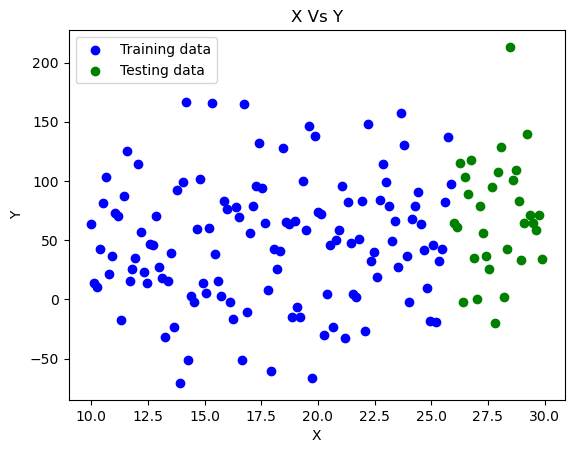

In [63]:
plot_data(X_train,y_train,X_test,y_test)

In [64]:

from torch import nn 

class MyFirstNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        
    def forward(self,x:torch.Tensor)->torch.Tensor:
        return self.weights*x + self.bias 
    
    

In [65]:
torch.manual_seed(42)
model1 = MyFirstNeuralNetwork()
model1.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

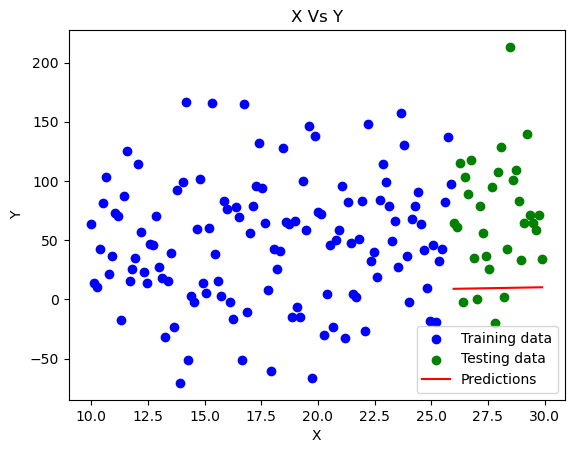

In [66]:
#predict before training 
with torch.inference_mode():
    y_pred = model1(X_test)
plot_data(X_train, y_train, X_test, y_test, predictions=y_pred)

In [67]:
# loss function 
loss_fn = nn.MSELoss()
# adam optimizer
optimizer = torch.optim.SGD(
    params = model1.parameters(),
    lr = 0.0001
)

In [68]:
# training loop 
epochs = 200
train_loss_list = []
test_loss_list = []

for epoch in range(epochs):
    # training mode
    model1.train()

    # get predictions on the training data
    train_preds = model1(X_train)

    # compute training loss
    loss = loss_fn(y_train, train_preds)

    # zero grad the optimizer
    optimizer.zero_grad()

    # backpropagate
    loss.backward()

    # step the optimizer
    optimizer.step()

    # testing mode
    model1.eval()
    with torch.inference_mode():
        # get the test preds
        test_preds = model1(X_test)

        # compute the test loss using the current epoch predictions
        test_loss = loss_fn(y_test, test_preds)

    train_loss_list.append(loss.item())
    test_loss_list.append(test_loss.item())

    if epoch % 10 == 0:
        print(f"Epochs {epoch + 1} | Train loss {loss:.6f} | Test loss {test_loss:.6f}")

Epochs 1 | Train loss 4459.573242 | Test loss 5455.183105
Epochs 11 | Train loss 3151.838379 | Test loss 2976.989258
Epochs 21 | Train loss 2837.136230 | Test loss 2406.706543
Epochs 31 | Train loss 2761.396240 | Test loss 2282.247070
Epochs 41 | Train loss 2743.158936 | Test loss 2258.554199
Epochs 51 | Train loss 2738.760742 | Test loss 2255.916504
Epochs 61 | Train loss 2737.691650 | Test loss 2256.781982
Epochs 71 | Train loss 2737.424072 | Test loss 2257.722412
Epochs 81 | Train loss 2737.349121 | Test loss 2258.305908
Epochs 91 | Train loss 2737.320312 | Test loss 2258.618896
Epochs 101 | Train loss 2737.302734 | Test loss 2258.776611
Epochs 111 | Train loss 2737.288330 | Test loss 2258.852783
Epochs 121 | Train loss 2737.274414 | Test loss 2258.887695
Epochs 131 | Train loss 2737.260254 | Test loss 2258.902100
Epochs 141 | Train loss 2737.246582 | Test loss 2258.906006
Epochs 151 | Train loss 2737.232910 | Test loss 2258.905762
Epochs 161 | Train loss 2737.218994 | Test loss 225

In [69]:
print(train_loss_list[0], train_loss_list[-1])
print(test_loss_list[0], test_loss_list[-1])

4459.5732421875 2737.165771484375
5455.18310546875 2258.88232421875


In [70]:
print(model1.state_dict())

OrderedDict([('weights', tensor([2.5681])), ('bias', tensor([0.3200]))])


In [71]:
w2 = 2.3836
b2 = 0.2436

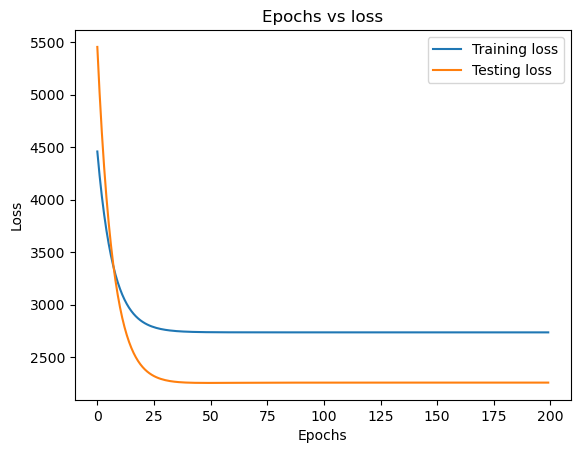

In [72]:
epochs = len(train_loss_list)
plt.plot(range(epochs), train_loss_list, label="Training loss")
plt.plot(range(epochs),test_loss_list,label="Testing loss")
plt.title("Epochs vs loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("0.5lr.png",dpi=300,bbox_inches="tight")
plt.show()

### comparison among two learning procedures

In [73]:
print(f"The differences between weights and bias obtained for same data using two different methods are: \n w={abs(w-w2):.3f} and b={abs(b-b2):.3f}")

The differences between weights and bias obtained for same data using two different methods are: 
 w=1.940 and b=0.474
